In [14]:
from langchain.tools import tool
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
load_dotenv()


True

In [4]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import random

In [10]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(
    max_results=5,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

In [12]:
tools = [search_tool]

In [16]:
llm_with_tools = llm.bind_tools([search_tool])

In [15]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [17]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)

    return {
        "messages": [response]
    }

tool_node = ToolNode(tools)

In [27]:
graph = StateGraph(ChatState)
graph.add_node("Chat Node", chat_node)
graph.add_node("tools", tool_node)

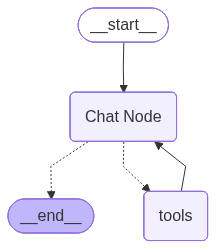

In [28]:
graph.add_edge(START, "Chat Node")
graph.add_conditional_edges("Chat Node", tools_condition)
graph.add_edge("tools", "Chat Node")
chatbot = graph.compile()

chatbot

In [29]:
chatbot.invoke(
    {
        "messages": [HumanMessage(content="what is the current weather 5 day forecast of dhaka.")]
    }
)

{'messages': [HumanMessage(content='what is the current weather 5 day forecast of dhaka.', additional_kwargs={}, response_metadata={}, id='ee4a615b-4352-40f0-8a8a-eff2e3fc9d0d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_NIwaO9pCjJrVnVo8nCxvWZrs', 'function': {'arguments': '{"query":"Dhaka 5 day weather forecast","search_depth":"advanced"}', 'name': 'tavily_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1281, 'total_tokens': 1308, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_29330a9688', 'id': 'chatcmpl-D1Pn4oTfXUIXqEMvztGzwBIS74w4L', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019bee50-ddea-7752-ac5b-cabc2f37d4